<a href="https://colab.research.google.com/github/Aaryan8597/AI-ML-AaryanLamichhane2408597-/blob/main/Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Data Understanding and Visualization:

Training set: (90, 128, 128, 3), labels: (90, 6)
Testing set: (30, 128, 128, 3), labels: (30, 6)


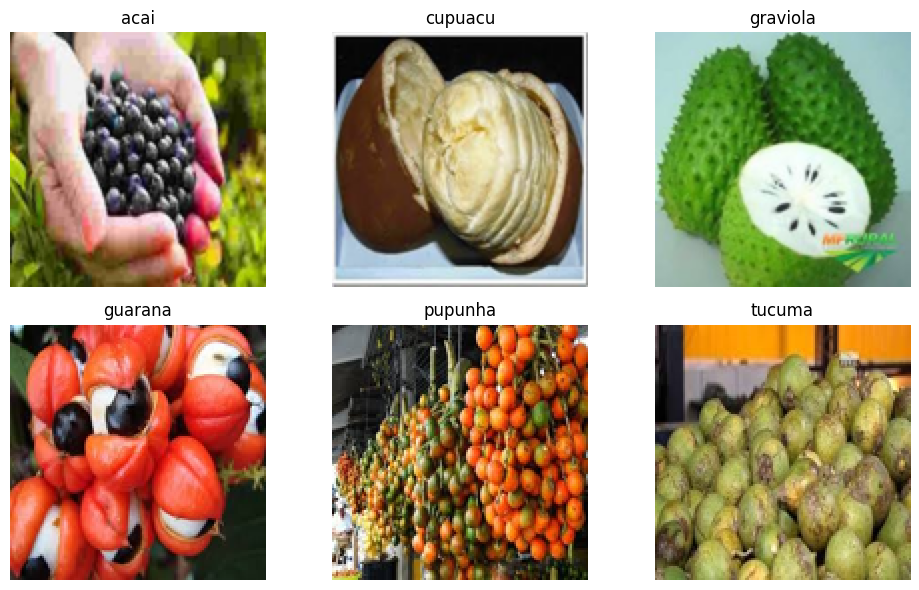

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image
import random

# defining path for datasets
train_dir = "/content/drive/MyDrive/AIML/Data/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AIML/Data/FruitinAmazon/test"

# image size
img_height, img_width = 128, 128

# function to load dataset
def load_data(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # sorted class names
    class_map = {name: i for i, name in enumerate(class_names)}
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # load image
            img = Image.open(img_path).convert("RGB")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels), class_names
# load training and testing datasets
x_train, y_train, class_names = load_data(train_dir)
x_test, y_test, _ = load_data(test_dir)
# reshape for CNN
x_train = x_train.reshape(-1, img_height, img_width, 3)
x_test = x_test.reshape(-1, img_height, img_width, 3)
# one-hot encoding
num_classes = len(class_names)
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)
# print dataset info
print(f"Training set: {x_train.shape}, labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, labels: {y_test.shape}")
rows = 2
cols = 3

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)

    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_width, img_height))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Check for Corrupt image

In [3]:
import os
from PIL import Image

# path to training data
train_dir = "/content/drive/MyDrive/AIML/Data/FruitinAmazon/train"

corrupted_images = []

# iterating through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # iterating through images
    for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)

        try:
            # try opening image
            with Image.open(img_path) as img:
                img.verify()  # checking if image is corrupted

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)

            # removing corrupted image
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


# Task-2 Loading and Preprocessing Image Data in Keras

In [4]:
import tensorflow as tf
#setting image  size and batch size
img_height = 128
img_width = 128
batch_size = 32

#splitting data into  80% training and 20% validation
validation_split = 0.2
#creating a layer to normalize the image (from 0-255 to 0-1)
rescale = tf.keras.layers.Rescaling(1./255)

#training the dataset with normalizaiton
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = True, validation_split = validation_split,
    subset = 'training', seed = 123)

# Normalizing Training images
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# loading the validation images from same folder
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = False, validation_split = validation_split,
    subset = 'validation', seed = 123)

#noramlizing validation images
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 Implement a CNN

## Convolutional Layer 1

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

#creating a CNN model
model = models.Sequential()

#first convolutional layer
model.add(layers.Conv2D(32, (3, 3), strides = 1, padding = 'same', input_shape = (128,128,3)))
#addind activation function
model.add(layers.ReLU())
#now doing the part of max pooling layers
model.add(layers.MaxPooling2D((2, 2), strides = 2))

#second convolutional layer
model.add(layers.Conv2D(32, (3, 3), strides = 1, padding = 'same'))
#adding activation funciton
model.add(layers.ReLU())
#now adding max pooling layer
model.add(layers.MaxPooling2D((2, 2), strides = 2))

#Fully Connected Network architecture
#falttening the layer
model.add(layers.Flatten())

#adding hidden layer 1 and 2
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dense(128, activation = 'relu'))

#output layer
model.add(layers.Dense(num_classes, activation = 'softmax'))


# Task 4 Compiling the model

In [8]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

# Task 5 training the model

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Recompile the model with sparse_categorical_crossentropy
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

checkpoint = ModelCheckpoint(
    "best_model.h5",        # file name
    monitor='val_loss',     # checking validation loss
    save_best_only=True     # for saving only best model
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

# Training the model
history = model.fit(train_ds, validation_data=val_ds, epochs=250, callbacks=[checkpoint, early_stop])

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.1649 - loss: 2.2491

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1667 - loss: 2.4408 - val_accuracy: 0.0000e+00 - val_loss: 2.0892
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.1950 - loss: 1.8736

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step - accuracy: 0.1944 - loss: 1.8549 - val_accuracy: 0.1111 - val_loss: 1.8680
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.3027 - loss: 1.6645

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.3611 - loss: 1.6487 - val_accuracy: 0.1111 - val_loss: 1.8660
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.3704 - loss: 1.5471

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 662ms/step - accuracy: 0.3611 - loss: 1.5458 - val_accuracy: 0.1667 - val_loss: 1.6193
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.5417 - loss: 1.3723

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 590ms/step - accuracy: 0.9028 - loss: 0.3601 - val_accuracy: 0.7778 - val_loss: 0.5495
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.8750 - loss: 0.3191 - val_accuracy: 0.8333 - val_loss: 0.6622
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9757 - loss: 0.2107

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 514ms/step - accuracy: 0.9583 - loss: 0.2382 - val_accuracy: 0.7778 - val_loss: 0.4827
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9954 - loss: 0.1213

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 594ms/step - accuracy: 0.9861 - loss: 0.1277 - val_accuracy: 0.8333 - val_loss: 0.3820
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 531ms/step - accuracy: 0.9861 - loss: 0.1261 - val_accuracy: 0.7222 - val_loss: 0.9068
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 780ms/step - accuracy: 0.9167 - loss: 0.1873 - val_accuracy: 0.7778 - val_loss: 0.6122
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 1.0000 - loss: 0.0380

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 518ms/step - accuracy: 1.0000 - loss: 0.0383 - val_accuracy: 0.8889 - val_loss: 0.2948
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9954 - loss: 0.0536

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step - accuracy: 0.9861 - loss: 0.0616 - val_accuracy: 0.9444 - val_loss: 0.2070
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 480ms/step - accuracy: 1.0000 - loss: 0.0507 - val_accuracy: 0.8889 - val_loss: 0.2457
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 1.0000 - loss: 0.0264 - val_accuracy: 0.8333 - val_loss: 0.4063
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 630ms/step - accuracy: 1.0000 - loss: 0.0243 - val_accuracy: 0.8333 - val_loss: 0.5793
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 778ms/step - accuracy: 1.0000 - loss: 0.0219 - val_accuracy: 0.8333 - val_loss: 0.5889
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 630ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 0.8333 - val_loss: 0.4423
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.8333 - val_loss: 0.3577
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.8333 - val_lo

# Task 6 : Evaluating the model

In [12]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

# Normalizing test data
test_ds = test_ds.map(lambda x, y: (x/255.0, y))

Found 30 files belonging to 6 classes.


In [13]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.8000 - loss: 0.6364
Test Loss: 0.6364274621009827
Test Accuracy: 0.800000011920929


# Task 7: Saving and loading the model

In [14]:
model.save("final_model.h5")
#loading the model
loaded_model = tf.keras.models.load_model("final_model.h5")
#evaluating the loaded model
loss, acc = loaded_model.evaluate(test_ds)
print("Loaded Model - Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step - accuracy: 0.8000 - loss: 0.6364
Loaded Model - Accuracy: 0.800000011920929


# Task 8 Prediciton and calssification report

In [17]:
import numpy as np
from sklearn.metrics import classification_report

#getting the predictions
predictions = model.predict(test_ds)
predicted_classes = np.argmax(predictions, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Print classification report
print(classification_report(y_true, predicted_classes))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.40      0.57         5
           2       0.56      1.00      0.71         5
           3       1.00      0.80      0.89         5
           4       1.00      1.00      1.00         5
           5       0.75      0.60      0.67         5

    accuracy                           0.80        30
   macro avg       0.86      0.80      0.79        30
weighted avg       0.86      0.80      0.79        30

